# 📉 Fire and Smoke Detection using YOLO
This project aims to build a robust object detection model to identify **Fire** and **Smoke** in various environments.
* **Framework:** Ultralytics YOLO
* **Dataset:** Custom Fire & Smoke Dataset

## 🛠 Step 1: Environment Setup & Libraries
Installing the necessary libraries for computer vision and model training.

In [5]:
import csv
import shutil
import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

## 🧹 Step 2: Data Cleaning & Preprocessing
In this step, we:
1. Filter out corrupted or empty image/label files.
2. Synchronize images with their corresponding labels.
3. Organize the data into a clean directory structure (`train`, `val`, `test`).

In [4]:
ROOT='/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data'
BAD_IMAGES_DIR='/kaggle/working/bad_images'
BAD_LABELS_DIR = '/kaggle/working/bad_labels'
CLEAN_ROOT = '/kaggle/working/clean_data'
REPORT_CSV = '/kaggle/working/data_clean_report.csv'

In [5]:
valid_extensions=('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(CLEAN_ROOT, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(CLEAN_ROOT, split, 'labels'), exist_ok=True)

os.makedirs(BAD_IMAGES_DIR, exist_ok=True)
os.makedirs(BAD_LABELS_DIR, exist_ok=True)


def is_valid_image(image_path):
    if not image_path.lower().endswith(valid_extensions):
        return False, 'invalid_extension'
    try:
        img = cv2.imread(image_path)
        if img is None or img.size == 0:
            return False, "corrupted_or_empty"
        h, w = img.shape[:2]
        if h < 10 or w < 10:
            return False, 'too_small'
        return True, 'valid'
    except Exception as e:
        return False, f'error_{str(e)}'

def is_valid_label(label_path):
    if not os.path.exists(label_path):
        return False, 'missing'
    if os.path.getsize(label_path) == 0:
        return False, 'empty_file'
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
            if not lines: return False, 'empty_content'
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5: return False, 'invalid_format'
        return True, 'valid'
    except:
        return False, 'read_error'

report_rows = []

for split in ["train", "val", "test"]:
    src_img_dir = os.path.join(ROOT, split, "images")
    src_lbl_dir = os.path.join(ROOT, split, "labels")
    dst_img_dir = os.path.join(CLEAN_ROOT, split, "images")
    dst_lbl_dir = os.path.join(CLEAN_ROOT, split, "labels")

    if not os.path.isdir(src_img_dir):
        print(f"Skipping missing directory: {src_img_dir}")
        continue
        
    print(f"\n Processing {split} split...")

    for fname in sorted(os.listdir(src_img_dir)):
        src_img_path = os.path.join(src_img_dir, fname)
        if not os.path.isfile(src_img_path): continue
        
        name_without_ext = os.path.splitext(fname)[0]
        src_lbl_path = os.path.join(src_lbl_dir, name_without_ext + ".txt")
        
        valid_img, img_status = is_valid_image(src_img_path)
        valid_lbl, lbl_status = is_valid_label(src_lbl_path)

        if valid_img and valid_lbl:
            shutil.copy2(src_img_path, dst_img_dir)
            shutil.copy2(src_lbl_path, dst_lbl_dir)
            report_rows.append([split, fname, "success"])
        else:
            shutil.copy2(src_img_path, BAD_IMAGES_DIR)
            if os.path.exists(src_lbl_path):
                shutil.copy2(src_lbl_path, BAD_LABELS_DIR)
            
            reason = f"img_{img_status}_lbl_{lbl_status}"
            report_rows.append([split, fname, reason])
            print(f"   ❌ Rejected: {fname} | Reason: {reason}")


df_report = pd.DataFrame(report_rows, columns=['split', 'filename', 'status'])
df_report.to_csv(REPORT_CSV, index=False)

print("\n" + "="*30)
print("FINAL SUMMARY")
print("="*30)
for split in ["train", "val", "test"]:
    clean_dir = os.path.join(CLEAN_ROOT, split, "images")
    if os.path.exists(clean_dir):
        count = len(os.listdir(clean_dir))
        print(f"✅ Clean {split.upper()}: {count} samples")
print(f"Report saved to: {REPORT_CSV}")


 Processing train split...
   ❌ Rejected: AoF00000.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00003.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00004.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00005.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00006.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00007.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00010.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00012.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00013.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00015.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00016.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00017.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00019.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00020.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00021.jpg | Reason: img_valid_lbl_empty_file
   ❌ Rejected: AoF00022.jpg

## 🖼️ Step 2.5: Data Sanity Check (Visualization)
Before starting the training, we must visualize a few samples from the **Clean Dataset**.
This ensures that:
1. Images are loaded correctly.
2. Bounding boxes (Labels) are perfectly aligned with the objects (Fire/Smoke).

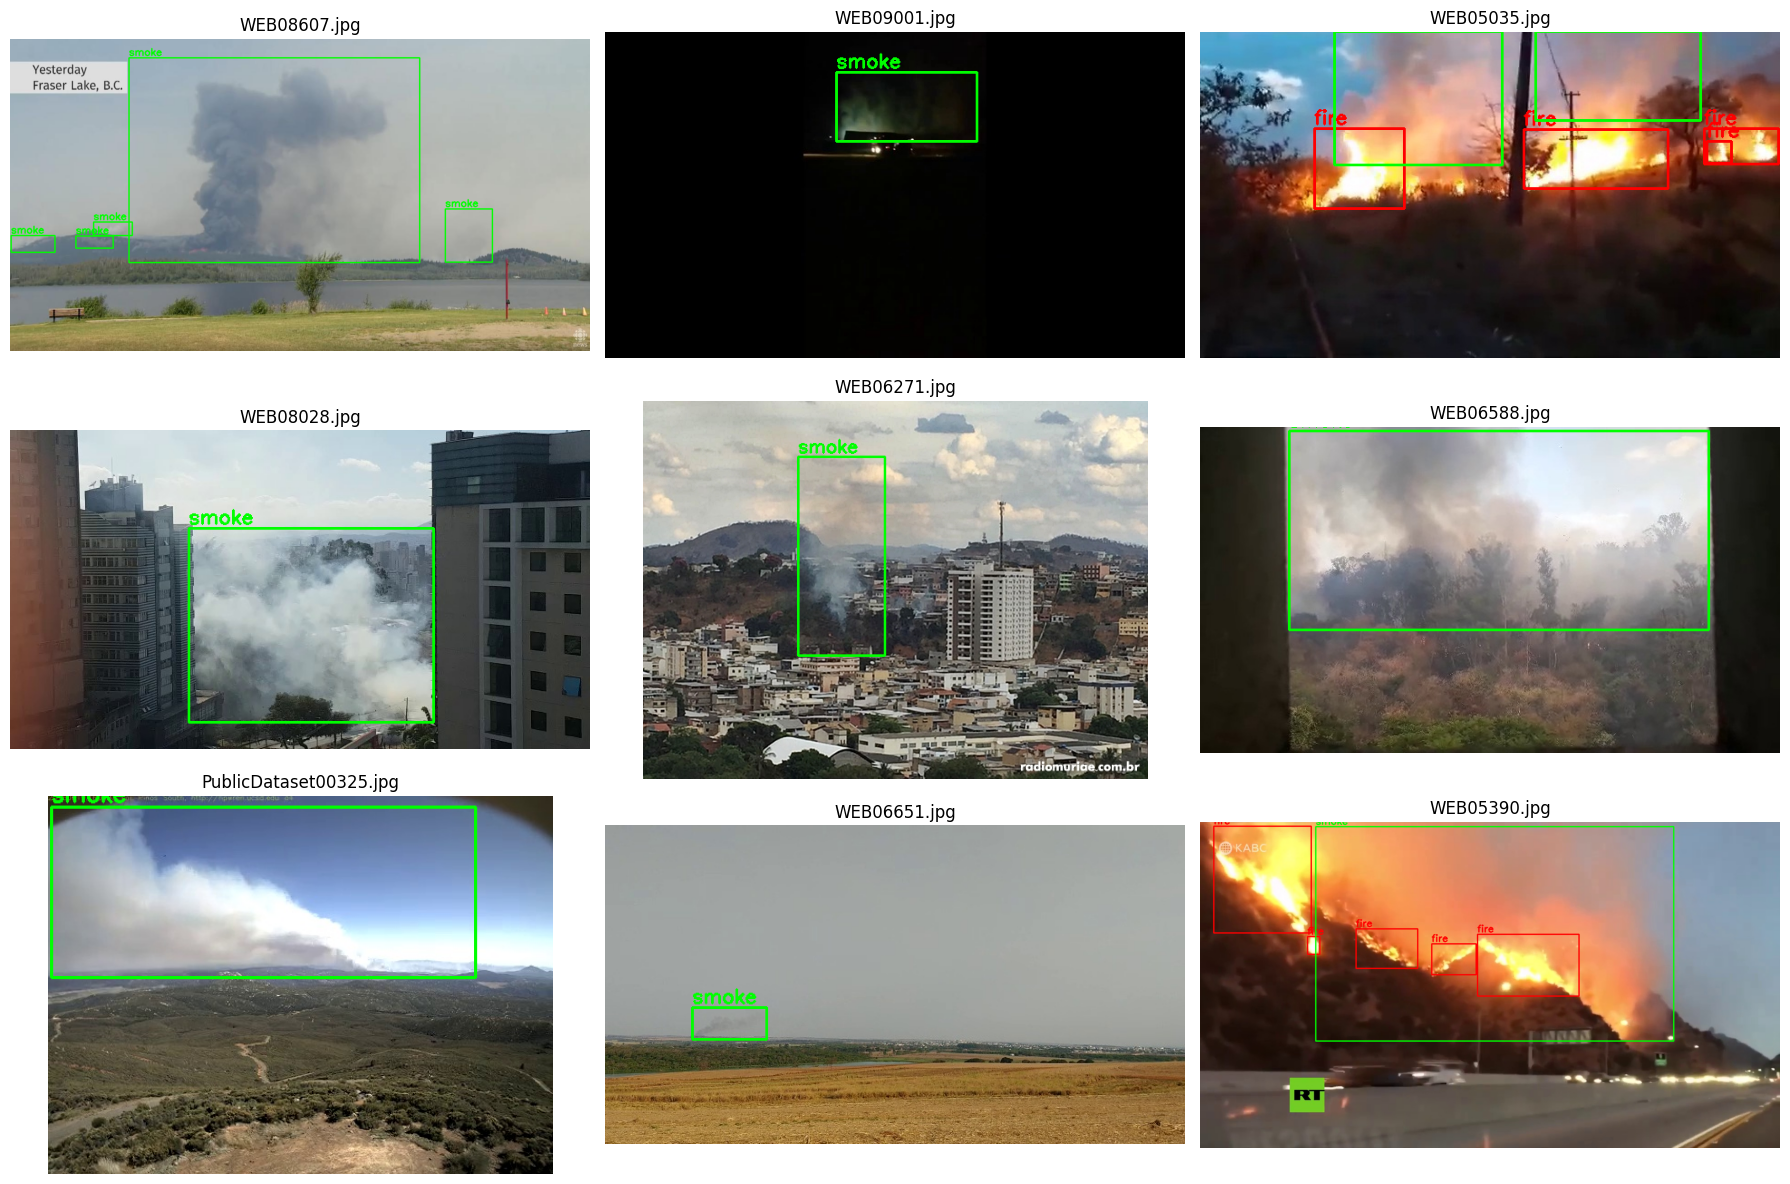

In [6]:
train_img_path = os.path.join(CLEAN_ROOT, 'train', 'images')
train_label_path = os.path.join(CLEAN_ROOT, 'train', 'labels')

sample_imgs = random.sample(os.listdir(train_img_path), 9)

def plot_image_with_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    label_file = label_path.replace('.jpg', '.txt').replace('.png', '.txt')
    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            for line in f.readlines():
                cls, x_center, y_center, bw, bh = map(float, line.strip().split())
                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)
                color = (0, 255, 0) if cls == 0 else (0, 0, 255)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cls_name = "smoke" if cls == 0 else "fire"
                cv2.putText(img, cls_name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

plt.figure(figsize=(18, 12))
for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(train_img_path, img_name)
    label_path = os.path.join(train_label_path, img_name)
    plt.subplot(3, 3, i+1)
    plt.imshow(plot_image_with_boxes(img_path, label_path))
    plt.axis('off')
    plt.title(img_name)
plt.tight_layout()
plt.show()


## 📊 Step 3: Exploratory Data Analysis (EDA)
Analyzing the distribution of classes (**Smoke** vs **Fire**) to ensure the dataset is balanced and ready for training.

Statistics for Clean Train Set:
🔥 Fire samples: 9638
💨 Smoke samples: 7794


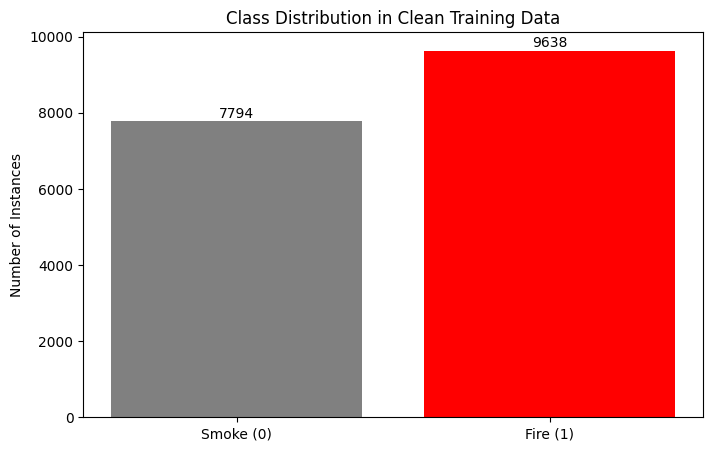

In [9]:
clean_labels_dir = os.path.join(CLEAN_ROOT, 'train', 'labels')

smoke, fire = 0, 0

if os.path.exists(clean_labels_dir):
    label_files = [os.path.join(clean_labels_dir, f) for f in os.listdir(clean_labels_dir) if f.endswith('.txt')]
    
    for lbl in label_files:
        with open(lbl, "r") as f:
            for line in f.readlines():
                parts = line.split()
                if len(parts) > 0:
                    cls = int(parts[0])
                    if cls == 0:
                        smoke += 1
                    elif cls == 1:
                        fire += 1

    print(f"Statistics for Clean Train Set:")
    print(f"🔥 Fire samples: {fire}")
    print(f"💨 Smoke samples: {smoke}")

    plt.figure(figsize=(8, 5))
    bars = plt.bar(["Smoke (0)", "Fire (1)"], [smoke, fire], color=['gray', 'red'])
    plt.title("Class Distribution in Clean Training Data")
    plt.ylabel("Number of Instances")
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom')
        
    plt.show()
else:
    print("Clean labels directory not found!")

## ⚙️ Step 4: Configuration File (YAML)
Creating the `data.yaml` file which acts as a map for the YOLO model to find the training and validation data paths and class names.

In [10]:
yaml_text = f"""
path: {CLEAN_ROOT}  
train: train/images  
val: val/images
test: test/images

nc: 2
names: ['smoke', 'fire']
"""

with open("/kaggle/working/data.yaml", "w", encoding="utf-8") as yf:
    yf.write(yaml_text.strip())
    
print("data.yaml is Done Created and optimized!")

data.yaml is Done Created and optimized!


In [14]:
!pip install -q ultralytics seaborn pyyaml opencv-python

## 🚀 Step 5: Model Training
We are using the diffrent architecture here to compare results

we use **YOLOv26** architecture
* **Image Size:** 640
* **Epochs:** 60
* **Device:** GPU (CUDA)

In [8]:
from ultralytics import YOLO
model_yolo26 = YOLO('yolo26m.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [17]:
result=model_yolo26.train(
    data='/kaggle/working/data.yaml',
    epochs=60,
    batch=32,
    imgsz=640,
    patience=10,
    verbose=True,
    project="/kaggle/working/runs",
    name="fire_smoke_yolo26m",
    device=0
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_yolo26m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

##  Performance Evaluation
Visualizing the training results, including:
* **Loss Curves:** To check for convergence.
* **mAP Curves:** To measure accuracy.
* **Confusion Matrix:** To see where the model might be misclassifying objects.

In [32]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

DATA_ROOT = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
RUNS_DIR  = "/kaggle/working/eval_results"
os.makedirs(RUNS_DIR, exist_ok=True)

yaml_content = f"""
path: {DATA_ROOT}
train: train/images
val: val/images
test: test/images
nc: 2
names: ['smoke', 'fire']
"""
TEST_YAML = "/kaggle/working/data.yaml"
with open(TEST_YAML, "w") as f:
    f.write(yaml_content.strip())

UPLOADED_MODEL_PATH = "/kaggle/input/models/antwanfares/best-2/pytorch/default/1/best-2.pt"
model = YOLO(UPLOADED_MODEL_PATH)

metrics = model.val(
    data=TEST_YAML,
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.50,
    device=0,
    project=RUNS_DIR,
    name="val_output",
    verbose=True,
)

mp      = metrics.box.mp
mr      = metrics.box.mr
map50   = metrics.box.map50
map5095 = metrics.box.map

# F1 per class
f1_scores = []
for i, name in model.names.items():
    p = mp
    r = mr
    f1 = 2 * (p * r) / (p + r + 1e-8)
    f1_scores.append(f1)
mean_f1 = np.mean(f1_scores)

print("\n" + "="*55)
print("  PERFORMANCE EVALUATION RESULTS")
print("="*55)
print(f"  Precision  : {mp:.4f}")
print(f"  Recall     : {mr:.4f}")
print(f"  F1-Score   : {mean_f1:.4f}")
print(f"  mAP@50     : {map50:.4f}")
print(f"  mAP@50-95  : {map5095:.4f}")
print()
print("  Per-class mAP@50:")
for i, name in model.names.items():
    f1 = 2 * (mp * mr) / (mp + mr + 1e-8)
    print(f"    {name:>8s} — mAP@50: {metrics.box.maps[i]:.4f}   F1: {f1:.4f}")
print("="*55)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,994 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 162.6±132.4 MB/s, size: 130.4 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels... 4295 images, 2005 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 646.3it/s 6.7s0.1s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB11243.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/saye

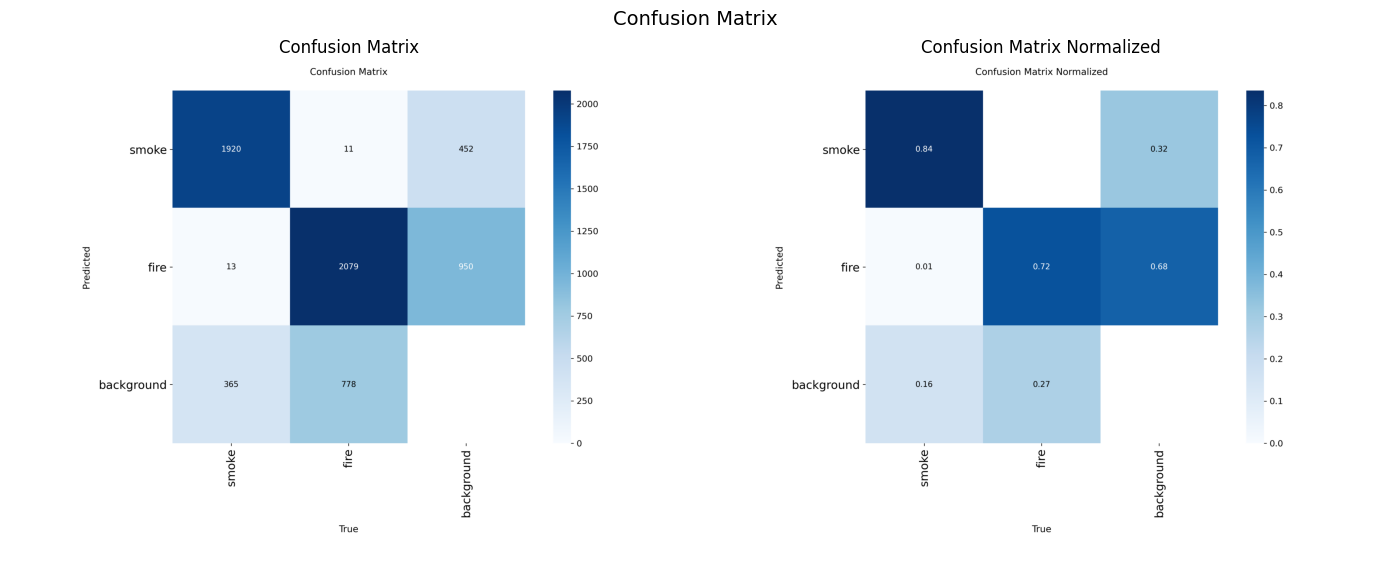

In [34]:
val_out  = f"{RUNS_DIR}/val_output"
cm_files = ["confusion_matrix.png", "confusion_matrix_normalized.png"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname in zip(axes, cm_files):
    path = os.path.join(val_out, fname)
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(fname.replace(".png","").replace("_"," ").title())
    ax.axis("off")
plt.suptitle("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.savefig(f"{RUNS_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## Inference on Test Images
Testing the trained model on unseen images from the test set to evaluate its real-world performance.

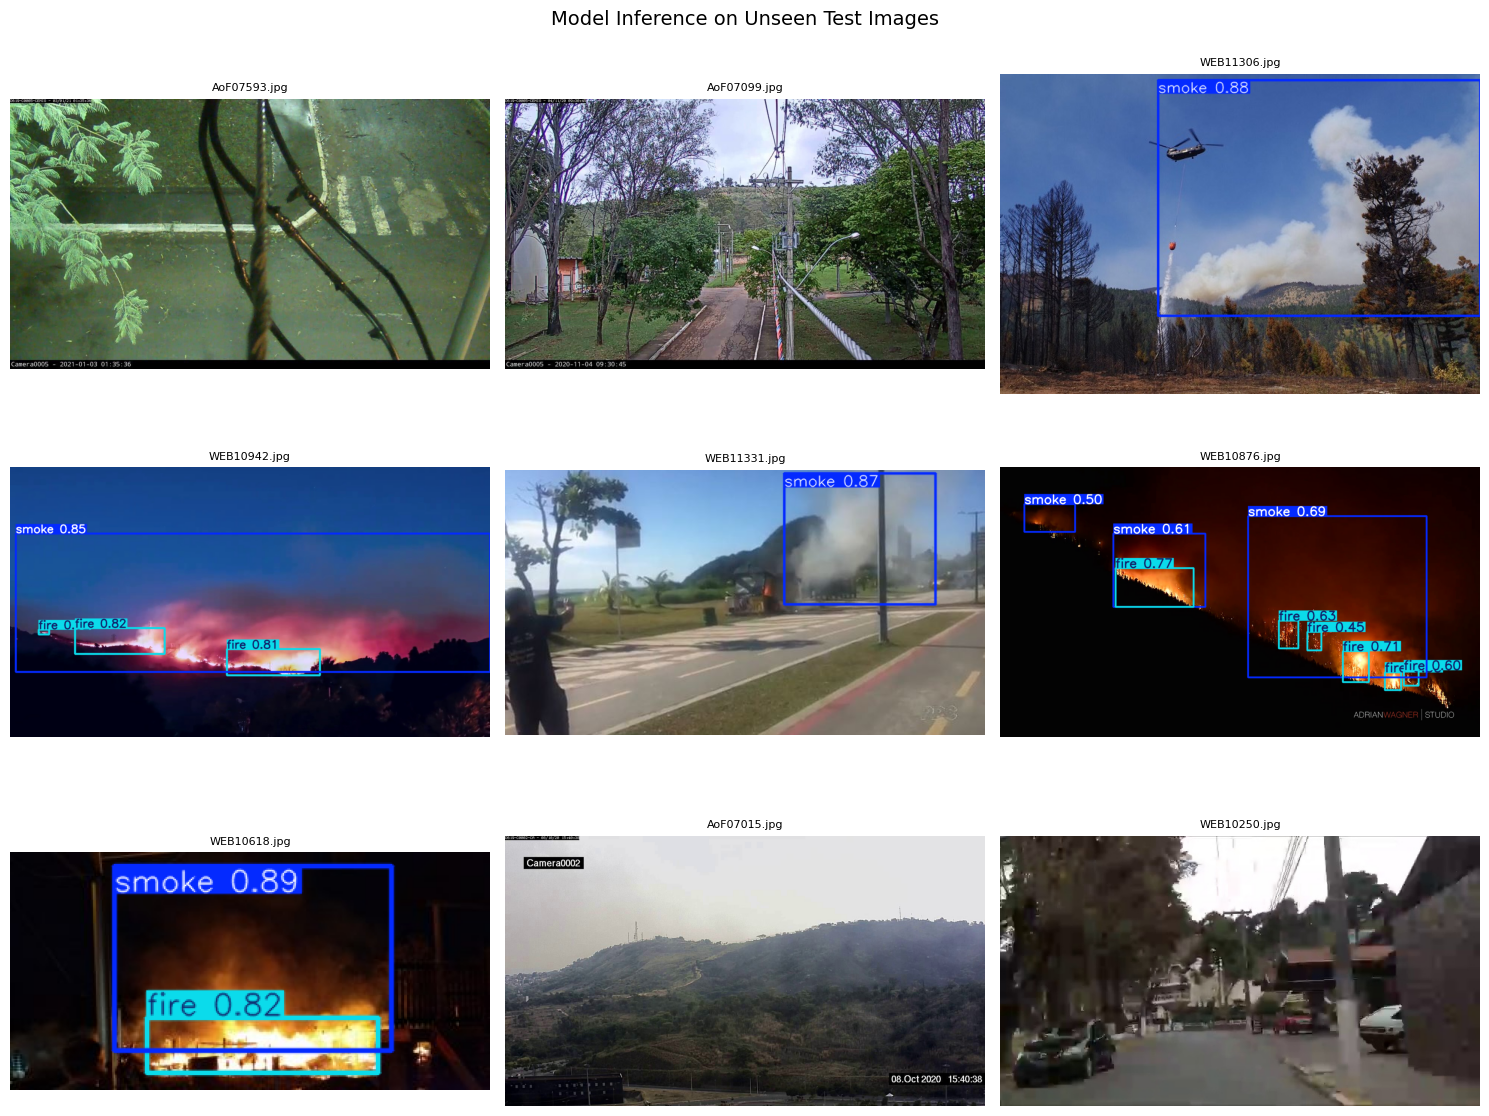

✅ Done — predictions on unseen test images saved.


In [38]:
import glob, random, cv2
import matplotlib.pyplot as plt

TEST_IMG_DIR = os.path.join(DATA_ROOT, "test", "images")
test_images  = glob.glob(os.path.join(TEST_IMG_DIR, "*"))
selected     = random.sample(test_images, min(9, len(test_images)))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, img_path in zip(axes.flatten(), selected):
    res     = model(img_path, conf=0.40, verbose=False)[0]
    img_out = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_out)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis("off")

plt.suptitle("Model Inference on Unseen Test Images", fontsize=14)
plt.tight_layout()
plt.savefig(f"{RUNS_DIR}/unseen_test_predictions.png", dpi=150)
plt.show()
print("✅ Done — predictions on unseen test images saved.")